In [1]:
from google.colab import drive #내 드라이브와 연동
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd './drive'

/content/drive


In [3]:
!ls
%cd 'MyDrive'

MyDrive
/content/drive/MyDrive


In [4]:
%cd Colab_Notebooks

/content/drive/MyDrive/Colab_Notebooks


In [5]:
!pwd

/content/drive/MyDrive/Colab_Notebooks


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from train_utils import train, test, main
import matplotlib.pyplot as plt

In [7]:
# CIFAR 10 데이터 사용
train_dataset = datasets.CIFAR10("./data", train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.CIFAR10("./data", train=False, download=True, transform=transforms.ToTensor())

Files already downloaded and verified
Files already downloaded and verified


Numer of Training Set 50000, Test Set 10000

Target: bird
Size of image: torch.Size([3, 32, 32])


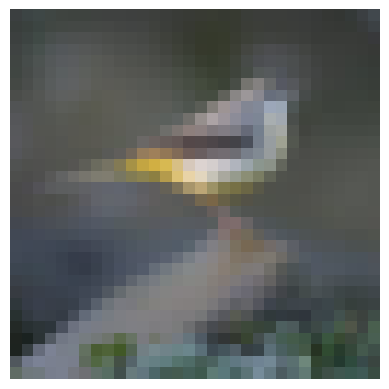

In [8]:
print("Numer of Training Set {}, Test Set {}\n".format(len(train_dataset), len(test_dataset)))
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

idx = torch.randint(0, len(train_dataset), (1,)).item()
random_image = train_dataset[idx][0]
target = train_dataset[idx][1]

print("Target: {}".format(classes[target]))
print("Size of image: {}".format(random_image.size()))

plt.imshow(random_image.permute(1,2,0).numpy())
plt.axis('off')
plt.show()

In [30]:
#데이터 로더 준비
BATCH = 128 #미니 배치 크기
DEVICE='cuda'
STEP = 30
PRINT_STEP = 180

train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH, shuffle=True)

#모델에 필요한 인자를 계산하면서 모델을 정의할수있다.
#이미지 데이터를 10개의 카테고리로 분류하는 문제기 때문에, CNN 모델의 최종 출력 형태는 (미니배치크기, 10)이 됨

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = lambda x: x.view(x.size(0), -1)

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=5, stride=1, padding=1) #input, output channel수를 계산해서 쓴다
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=2, stride=1, padding=0)

        self.relu = nn.ReLU(inplace=True) #activation function
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) #maxpool layer
        self.fc = nn.Linear(784, 10) #fully connected layer

    def forward(self, x):
        ## convolution layer
        #input (batch, 3, 32, 32)
        #conv1 (batch, 8, 30, 30)
        #pool1 (batch, 8, 15, 15)
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        #conv2 (batch, 16, 14, 14)
        #pool2 (batch, 16, 7, 7)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        #flatten
        x = self.flatten(x)
        x = self.fc(x)
        return x

torch.manual_seed(70)
model = CNN().to(DEVICE)
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [ ]:
main(model=model,
     train_loader = train_loader,
     test_loader = test_loader,
     loss_func = loss_function,
     optimizer = optimizer,
     n_step = STEP,
     device = DEVICE,
     save_path = "cifar10_ch3_model.pt",
     print_step = PRINT_STEP)

Train Step: 1 (00.00%)  	Loss: 2.3077
Train Step: 1 (46.08%)  	Loss: 1.8393
Train Step: 1 (92.16%)  	Loss: 1.6284
Test set: Average loss: 1.5948, Accuracy: 4308/10000 (43.08%)

Train Step: 2 (00.00%)  	Loss: 1.6247
Train Step: 2 (46.08%)  	Loss: 1.4250
Train Step: 2 (92.16%)  	Loss: 1.5276
Test set: Average loss: 1.5055, Accuracy: 4675/10000 (46.75%)
discard previous state, best model state saved!

Train Step: 3 (00.00%)  	Loss: 1.4729
Train Step: 3 (46.08%)  	Loss: 1.4804
Train Step: 3 (92.16%)  	Loss: 1.3987
Test set: Average loss: 1.4518, Accuracy: 4819/10000 (48.19%)
discard previous state, best model state saved!

Train Step: 4 (00.00%)  	Loss: 1.3444
Train Step: 4 (46.08%)  	Loss: 1.5382
Train Step: 4 (92.16%)  	Loss: 1.4649
Test set: Average loss: 1.4035, Accuracy: 5003/10000 (50.03%)
discard previous state, best model state saved!

Train Step: 5 (00.00%)  	Loss: 1.2704
Train Step: 5 (46.08%)  	Loss: 1.3411
Train Step: 5 (92.16%)  	Loss: 1.3383
Test set: Average loss: 1.3630, Ac

In [ ]:
# 좀 더 큰 CNN 모델로 학습하기
from custom_cnn import CNN
torch.cuda.manual_seed(70)

BATCH = 128
STEP = 20
PRINT_STEP = 180

config = [('ch_in', 3), ('n_in', 32),
          ('conv1', (32, 7, 1, 1)), ('pool1', 2),
          ('conv2', (64, 5, 1, 1)), ('pool2', 2),
          ('conv3', (128, 3, 1, 0)), ('pool3', 2),
          ('fc', (250, 50, 10))]

train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH, shuffle=True)

model = CNN(config).to(DEVICE)

loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

main(model=model,
     train_loader=train_loader,
     test_loader=test_loader,
     loss_func=loss_function,
     optimizer=optimizer,
     n_step=STEP,
     device=DEVICE,
     save_path='cifar10_bigger_model.pt',
     print_step=PRINT_STEP)

Train Step: 1 (00.00%)  	Loss: 2.3270
Train Step: 1 (46.08%)  	Loss: 1.3272
Train Step: 1 (92.16%)  	Loss: 1.1724
Test set: Average loss: 1.1699, Accuracy: 5742/10000 (57.42%)

Train Step: 2 (00.00%)  	Loss: 0.9998
Train Step: 2 (46.08%)  	Loss: 1.1047
Train Step: 2 (92.16%)  	Loss: 0.9062
Test set: Average loss: 1.0475, Accuracy: 6320/10000 (63.20%)
discard previous state, best model state saved!

Train Step: 3 (00.00%)  	Loss: 0.7805
Train Step: 3 (46.08%)  	Loss: 0.6471
Train Step: 3 (92.16%)  	Loss: 0.8667
Test set: Average loss: 0.9037, Accuracy: 6774/10000 (67.74%)
discard previous state, best model state saved!

Train Step: 4 (00.00%)  	Loss: 0.6239
Train Step: 4 (46.08%)  	Loss: 0.8677
Train Step: 4 (92.16%)  	Loss: 0.7273
Test set: Average loss: 0.8800, Accuracy: 6988/10000 (69.88%)
discard previous state, best model state saved!

Train Step: 5 (00.00%)  	Loss: 0.6555
Train Step: 5 (46.08%)  	Loss: 0.5864
Train Step: 5 (92.16%)  	Loss: 0.5292
Test set: Average loss: 0.8879, Ac

In [32]:
#모델 클래스 별 예측 정확도 확인하기
import torch
import torch.nn as nn
from torch.utils.data import dataloader
from torchvision import datasets, transforms
from custom_cnn import CNN

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

test_dataset = datasets.CIFAR10('./data', train=False, transform=transforms.ToTensor())
DEVICE = 'cuda'
BATCH=128
test_loader = DataLoader(test_dataset, batch_size=BATCH, shuffle=True)

config = [('ch_in', 3), ('n_in', 32),
                   ('conv1', (32, 7, 1, 1)), ('pool1', 2),
                   ('conv2', (64, 5, 1, 1)), ('pool2', 2),
                   ('conv3', (128, 3, 1, 0)), ('pool3', 2),
                   ('fc', (250, 50, 10))]

model = CNN(config).to(DEVICE)
model_path = 'cifar10_bigger_model.pt'
model.load_state_dict(torch.load(model_path))

#클래스별로 맞춘 개수 계산하는 함수
def cal_correct_by_class(model, test_loader, device):
  total = torch.zeros(10) #다 0에서 시작
  correct = torch.zeros(10)
  with torch.no_grad():
    for data, target in test_loader:
      output = model(data.to(device)) #항상 같은 디바이스에 두어야된다
      pred = output.cpu().softmax(1).argmax(1) #행방향 확률 합1, 그중 최고 찾기
      correct_idx = pred.masked_select((pred == target)) #pred가 target과 동일한 것들의 아이디만 반환
      correct += torch.zeros(correct_idx.size(0),10).scatter(1,correct_idx.view(-1,1),1).sum(0) #correct_idx에 해당하는 값들만 1이 되고 나머지는 0으로
      total += torch.zeros(target.size(0),10).scatter(1, target.view(-1,1),1).sum(0)

  percentage = correct/total
  return percentage

percentage = cal_correct_by_class(model, test_loader, DEVICE)

for cls_name, percent in zip (classes, percentage):
  print("{} \t: {:05.2f}%".format(cls_name, percent*100))

<ipython-input-32-78aec77e16af>:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


plane 	: 83.70%
car 	: 82.70%
bird 	: 65.90%
cat 	: 59.60%
deer 	: 70.40%
dog 	: 61.10%
frog 	: 87.70%
horse 	: 75.70%
ship 	: 84.40%
truck 	: 82.50%


3.1.5 case study (기존 모델들을 알아보기)

In [28]:
#Alex Net
class AlexNet(nn.Module):
  def __init__(self, n_in=32, output_size=10):
    super().__init__() #nn.Module을 받으면 꼭 super!!
    """
    config:
    -kernel: c_out, k, s, p
    -pool: maxpool, (kernel_size=3, stride=2, padding=0)
    """

    self.n_in = n_in
    config = [(96, 11, 4, 0), "M", (256, 5, 1, 2), "M", (384, 3, 1, 1,), (384, 3, 1, 1), (256, 3, 1, 1), "M"]
    #커널 수, 커널사이즈, 스트라이드 사이즈, 패딩사이즈, 맥스풀링

    self.convs = self.make_layers(config)
    self.fc = nn.Sequential(nn.Linear(self._get_fc_input(config), 4096),
                            nn.Linear(4096, 4096),
                            nn.Linear(4096, output_size))

  def forward(self, x):
    out=self.convs(x)
    out=self.view(out.size(0), -1)
    out=self.fc(out)
    return out

  def _make_layers(self, config):
    layers=[]
    ch_in=3
    for x in config:
      if x == 'M':
        layers += [nn.MaxPool2d(kernel_size=3, stride=2)]
      else:
        ch_out, k, s, p = x
        layers += [nn.Conv2d(ch_in, ch_out, kernel_size=k, stride=s, padding=p),
                   nn.ReLU(inplace=True)]
        ch_in = ch_out
    return nn.Sequential(*layers)

  def _get_fc_input(self, config):
    n_in = self.n_in
    for x in config:
      if x == "M":
        pool_k, pool_s = 3, 2
        pool_n_out = (n_in - pool_k) // pool_s + 1
        n_in = pool_n_out
      else:
        ch_out, k, s, p = x
        conv_n_out = (n_in - k + 2*p) // s + 1
        n_in = conv_n_out
    fc_layer = int(ch_out*n_in*n_in)
    return fc_layer

In [16]:
#VGG-16
#매번 풀링마다 출력 이미지의 높이와 너비가 1/2로 줄어들고, 출력 채널의 수는 2배 혹은 3배로 늘어나게 만들었다.

class VGG(nn.Module):
  def __init__(self, vgg_name, n_in=32, output_size=10):
    super(VGG, self).__init__()
    self.n_in = n_in
    config = {
        "VGG11": [64, "M", 128, "M", 256, 256, "M", 512, 512, "M", 512, 512, "M"],
        "VGG13": [64, 64, "M", 128, 128, "M", 256, 256, "M", 512, 512, "M", 512, 512, "M"],
        "VGG16": [64, 64, "M", 128, 128, "M", 256, 256, 256, "M",512, 512, 512, "M", 512, 512, 512, "M"],
        "VGG19": [64, 64, "M", 128, 128, "M", 256, 256, 256, 256, "M", 512, 512, 512, 512, "M", 512, 512, 512, 512, "M"]
    }

    self.convs = self._make_layers(config[vgg_name])
    self.fc = nn.Sequential(
        nn.Linear(self._get_fc_input(config[vgg_name]), 4096),
        nn.Linear(4096, 4096),
        nn.Linear(4096, output_size),
    )

  def forward(self, x):
    out=self.convs(x)
    out=out.view(out.size(0), -1)
    out=self.fc(out)
    return out

  def _make_layers(self, config):
    layers=[]
    in_channels=3
    for x in config:
      if x == "M":
        layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
      else:
        layers += [nn.Conv2d(in_channels, x, kernel_size=3, padding=1),
                   nn.BatchNorm2d(x),
                   nn.ReLU(inplace=True)]
        in_channels = x
    return nn.Sequential(*layers)

  def _get_fc_input(self, config):
    n_in = self.n_in
    for x in config:
      if x == "M":
        pool_k, pool_s = 2, 2
        pool_n_out = (n_in - pool_k) // pool_s + 1
        n_in = pool_n_out
      else:
        ch_out = x
        k, s, p = 3, 1, 1
        conv_n_out = (n_in - k + 2*p) // s + 1
        n_in = conv_n_out
    fc_input = int(ch_out*n_in*n_in)
    return fc_input



In [17]:
torch.cuda.manual_seed(70)

BATCH = 128
STEP = 20
PRINT_STEP = 180
DEVICE = 'cuda'

config = "VGG16"

train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH, shuffle=True)

model = VGG(config).to(DEVICE)

loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

main(model=model,
     train_loader=train_loader,
     test_loader=test_loader,
     loss_func=loss_function,
     optimizer=optimizer,
     n_step=STEP,
     device=DEVICE,
     save_path='cifar10_vgg16.pt',
     print_step=PRINT_STEP)

Train Step: 1 (00.00%)  	Loss: 2.2821
Train Step: 1 (46.08%)  	Loss: 2.2644
Train Step: 1 (92.16%)  	Loss: 1.8333
Test set: Average loss: 1.8718, Accuracy: 2326/10000 (23.26%)

Train Step: 2 (00.00%)  	Loss: 1.9371
Train Step: 2 (46.08%)  	Loss: 1.7034
Train Step: 2 (92.16%)  	Loss: 1.5124
Test set: Average loss: 1.5349, Accuracy: 4033/10000 (40.33%)
discard previous state, best model state saved!

Train Step: 3 (00.00%)  	Loss: 1.5424
Train Step: 3 (46.08%)  	Loss: 1.3428
Train Step: 3 (92.16%)  	Loss: 1.1570
Test set: Average loss: 1.3517, Accuracy: 5027/10000 (50.27%)
discard previous state, best model state saved!

Train Step: 4 (00.00%)  	Loss: 1.1391
Train Step: 4 (46.08%)  	Loss: 1.1286
Train Step: 4 (92.16%)  	Loss: 0.7467
Test set: Average loss: 1.0519, Accuracy: 6451/10000 (64.51%)
discard previous state, best model state saved!

Train Step: 5 (00.00%)  	Loss: 1.1160
Train Step: 5 (46.08%)  	Loss: 1.0372
Train Step: 5 (92.16%)  	Loss: 0.8845
Test set: Average loss: 0.9289, Ac